In [1]:
# ==============================================================================
# CELL 1: SETUP AND IMPORTS
# ==============================================================================

# Standard Library
import os
import shutil
import random
import itertools
import time

# Numerical & Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch & Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
import timm

# Scikit-Learn (Machine Learning)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.model_selection import train_test_split

# Extra ML/Stats Tools
from scipy.special import softmax
from sklearn.manifold import TSNE

# Progress Bar
from tqdm import tqdm

# Kaggle
import kagglehub

print("All libraries imported successfully.")


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

All libraries imported successfully.


In [2]:
# ==============================================================================
# CELL 2: DOWNLOAD AND PREPARE DATASET
# ==============================================================================
# --- Download from Kaggle ---
path = kagglehub.dataset_download("mdriyadhossain/ai-medleafx")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/


In [3]:
dataset_path = "/kaggle/input"
print("Verified path to dataset files:", dataset_path)

# Assuming the structure is dataset_path -> 'Resized Image' -> Plant Type -> Disease/Health Status -> Images
resized_image_base_path = os.path.join(dataset_path, 'Resized Image')

all_class_dirs = []
class_counts = {}

print("\nExploring dataset structure and counting images:")

try:
    # List plant type directories within 'Resized Image'
    plant_type_dirs = [d for d in os.listdir(resized_image_base_path) if os.path.isdir(os.path.join(resized_image_base_path, d))]
    print(f"\nFound {len(plant_type_dirs)} plant types:", plant_type_dirs)

    if not plant_type_dirs:
        print("No plant type directories found within 'Resized Image'. Cannot proceed with expected structure.")
    else:
        # Iterate through each plant type directory
        for plant_type_dir in plant_type_dirs:
            plant_type_path = os.path.join(resized_image_base_path, plant_type_dir)

            # List disease/health status directories within each plant type
            status_dirs = [d for d in os.listdir(plant_type_path) if os.path.isdir(os.path.join(plant_type_path, d))]
            print(f"\nExploring '{plant_type_dir}': Found {len(status_dirs)} status categories:", status_dirs)

            if not status_dirs:
                print(f"No status directories found within '{plant_type_dir}'.")
            else:
                # Iterate through each status directory (these are the actual classes)
                for status_dir in status_dirs:
                    class_name = f"{plant_type_dir}_{status_dir}" # Combine plant type and status for a unique class name
                    class_path = os.path.join(plant_type_path, status_dir)
                    all_class_dirs.append(class_name)

                    # Count image files in the class directory
                    image_files_in_class = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg','.JPG'))]
                    class_counts[class_name] = len(image_files_in_class)
                    print(f"- {class_name}: {class_counts[class_name]} images")

        # Determine the total number of classes
        num_classes = len(all_class_dirs)
        print(f"\nTotal number of classes: {num_classes}")

        # Display class distribution summary
        print("\nClass distribution:")
        for class_name, count in class_counts.items():
            print(f"- {class_name}: {count}")

        # Calculate total number of images
        total_images = sum(class_counts.values())
        print(f"\nTotal number of images: {total_images}")

except FileNotFoundError:
    print(f"Error: The directory '{resized_image_base_path}' was not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


print("\nDataset exploration and counting complete.")

Verified path to dataset files: /kaggle/input

Exploring dataset structure and counting images:

Found 4 plant types: ['Sojina', 'Neem', 'Camphor', 'HariTaki']

Exploring 'Sojina': Found 3 status categories: ['Yellow Leaf', 'Healthy Leaf', 'Bacterial Spot']
- Sojina_Yellow Leaf: 814 images
- Sojina_Healthy Leaf: 860 images
- Sojina_Bacterial Spot: 804 images

Exploring 'Neem': Found 4 status categories: ['Powdery Mildew', 'Yellow Leaf', 'Healthy Leaf', 'Shot Hole Leaf']
- Neem_Powdery Mildew: 854 images
- Neem_Yellow Leaf: 854 images
- Neem_Healthy Leaf: 1021 images
- Neem_Shot Hole Leaf: 834 images

Exploring 'Camphor': Found 3 status categories: ['Healthy Leaf', 'Shot Hole', 'Bacterial Spot']
- Camphor_Healthy Leaf: 800 images
- Camphor_Shot Hole: 795 images
- Camphor_Bacterial Spot: 801 images

Exploring 'HariTaki': Found 3 status categories: ['Healthy Leaf', 'Shot Hole', 'Bacterial Spot']
- HariTaki_Healthy Leaf: 816 images
- HariTaki_Shot Hole: 802 images
- HariTaki_Bacterial Spot

In [4]:
# ==============================================================================
# CELL 3: DATA SPLITTING
# ==============================================================================

# Define paths
original_base_dir = os.path.join(dataset_path, 'Resized Image')
new_base_dir = '/content/data'

# Collect image paths and labels
data = []
for plant in os.listdir(original_base_dir):
    for status in os.listdir(os.path.join(original_base_dir, plant)):
        label = f"{plant}_{status}"
        path = os.path.join(original_base_dir, plant, status)
        for fname in os.listdir(path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png','.JPG')):
                data.append({'path': os.path.join(path, fname), 'label': label})

df = pd.DataFrame(data)

# Split dataset: 80% train, 10% val, 10% test
train_val, test = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)
train, val = train_test_split(train_val, test_size=0.1, stratify=train_val['label'], random_state=42)
# Output summary
total = len(df)
print(f"\n Dataset Split Summary:")
print(f"- Total images: {total}")
print(f"- Training set : {len(train):5d} images ({len(train)/total:.1%})")
print(f"- Validation set: {len(val):5d} images ({len(val)/total:.1%})")
print(f"- Test set     : {len(test):5d} images ({len(test)/total:.1%})\n")

# Copy files
for split_df, split in zip([train, val, test], ['train', 'val', 'test']):
    print(f" Copying {split} files...")
    for _, row in split_df.iterrows():
        dst_dir = os.path.join(new_base_dir, split, row['label'])
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy(row['path'], os.path.join(dst_dir, os.path.basename(row['path'])))
    print(f" {split.capitalize()} files copied: {len(split_df)}")

print("\n All files have been split and copied successfully.")


 Dataset Split Summary:
- Total images: 10858
- Training set :  8794 images (81.0%)
- Validation set:   978 images (9.0%)
- Test set     :  1086 images (10.0%)

 Copying train files...
 Train files copied: 8794
 Copying val files...
 Val files copied: 978
 Copying test files...
 Test files copied: 1086

 All files have been split and copied successfully.


In [5]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [6]:
# ============================================================================
# DATA LOADING
# ============================================================================
from torch.utils.data import Dataset
from PIL import Image

class ImageDataset(Dataset):
    """Custom dataset for image classification"""
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


def get_dinov2_transforms(is_training=False, img_size=224):
    """Get DINOv2-specific transforms"""
    if is_training:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

In [7]:


class DINOv2FeatureExtractor(nn.Module):
    """
    DINOv2 Vision Transformer as a feature extractor
    Base model: ViT-Base/14 trained on LVD-142M dataset
    """
    def __init__(self, model_name='vit_base_patch14_dinov2.lvd142m', pretrained=True, freeze_backbone=True):
        super().__init__()

        # Load pretrained DINOv2 model
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)

        # Freeze backbone if specified
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Get feature dimension
        self.feature_dim = self.backbone.num_features

    def forward(self, x):
        """Extract features from images"""
        return self.backbone(x)


class DINOv2Classifier(nn.Module):
    """
    Complete DINOv2 model with classification head
    """
    def __init__(self, num_classes, model_name='vit_base_patch14_dinov2.lvd142m',
                 pretrained=True, freeze_backbone=True, dropout=0.1):
        super().__init__()

        # Feature extractor
        self.feature_extractor = DINOv2FeatureExtractor(
            model_name=model_name,
            pretrained=pretrained,
            freeze_backbone=freeze_backbone
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.feature_extractor.feature_dim),
            nn.Dropout(dropout),
            nn.Linear(self.feature_extractor.feature_dim, num_classes)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        logits = self.classifier(features)
        return logits

    def get_features(self, x):
        """Extract features without classification"""
        return self.feature_extractor(x)

In [8]:
# ============================================================================
# TRAINING SETUP
# ============================================================================

def create_model(num_classes, freeze_backbone=True, model_variant='base'):
    """
    Create DINOv2 model with different variants

    Args:
        num_classes: Number of output classes
        freeze_backbone: Whether to freeze the backbone
        model_variant: 'small', 'base', 'large', or 'giant'
    """
    model_names = {
        'small': 'vit_small_patch14_dinov2.lvd142m',
        'base': 'vit_base_patch14_dinov2.lvd142m',
        'large': 'vit_large_patch14_dinov2.lvd142m',
        'giant': 'vit_giant_patch14_dinov2.lvd142m'
    }

    model_name = model_names.get(model_variant, model_names['base'])

    model = DINOv2Classifier(
        num_classes=num_classes,
        model_name=model_name,
        pretrained=True,
        freeze_backbone=freeze_backbone,
        dropout=0.1
    )

    return model


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    # Example configuration (these variables are redefined globally later)
    # NUM_CLASSES is now defined globally after data loading setup
    BATCH_SIZE = 32
    IMG_SIZE = 518 # Changed from 224 to 518 to match DINOv2 model's expected input size
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # The actual model instantiation will happen globally after data loaders are set up
    # For the purpose of this __main__ block, we can keep this for testing model creation
    # For real use, ensure `model` and `NUM_CLASSES` are globally defined before this `if __name__` block
    # or pass them as arguments to functions that need them.

    # Placeholder for NUM_CLASSES if this block is run independently
    _num_classes_placeholder = 10 # This will be overridden by the global NUM_CLASSES

    # Instantiate the model for testing within this block
    model = create_model(
        num_classes=_num_classes_placeholder,
        freeze_backbone=True,
        model_variant='base'
    )
    model = model.to(DEVICE)

    print(f"Model created successfully!")
    print(f"Feature dimension: {model.feature_extractor.feature_dim}")
    print(f"Number of classes: {_num_classes_placeholder}") # Using placeholder for example

    # Example: Load and prepare data (these are not the actual datasets/loaders)
    train_image_paths = ['path/to/image1.jpg', 'path/to/image2.jpg']
    train_labels = [0, 1]

    train_transform = get_dinov2_transforms(is_training=True, img_size=IMG_SIZE)
    val_transform = get_dinov2_transforms(is_training=False, img_size=IMG_SIZE)

    # These example dataset/loader creations are commented out as they will be defined globally
    # train_dataset = ImageDataset(train_image_paths, train_labels, train_transform)
    # train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    # Example forward pass
    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    with torch.no_grad():
        output = model(dummy_input)
        features = model.get_features(dummy_input)

    print(f"\nOutput shape: {output.shape}")
    print(f"Features shape: {features.shape}")

    # Model summary
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\nTotal parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Frozen parameters: {total_params - trainable_params:,}")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model created successfully!
Feature dimension: 768
Number of classes: 10

Output shape: torch.Size([1, 10])
Features shape: torch.Size([1, 768])

Total parameters: 86,588,938
Trainable parameters: 9,226
Frozen parameters: 86,579,712


In [9]:
# ============================================================================
# DEFINE GLOBAL VARIABLES FOR DATA LOADING AND MODEL
# ============================================================================

# Get the actual number of classes from the dataset exploration
NUM_CLASSES = len(all_class_dirs)
print(f"Global NUM_CLASSES set to: {NUM_CLASSES}")

# Create a mapping from class name string to integer label
class_to_idx = {class_name: i for i, class_name in enumerate(sorted(all_class_dirs))}
idx_to_class = {i: class_name for class_name, i in class_to_idx.items()}
print(f"Class mapping created: {class_to_idx}")

# Define device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Instantiate the DINOv2 model globally
# Using 'base' variant and freezing backbone for feature extraction
m_model = create_model(
    num_classes=NUM_CLASSES,
    freeze_backbone=True,
    model_variant='base'
)
m_model = m_model.to(DEVICE)
print("Global DINOv2 model instantiated and moved to device.")

BATCH_SIZE = 32
IMG_SIZE = 518 # DINOv2 default input size


Global NUM_CLASSES set to: 13
Class mapping created: {'Camphor_Bacterial Spot': 0, 'Camphor_Healthy Leaf': 1, 'Camphor_Shot Hole': 2, 'HariTaki_Bacterial Spot': 3, 'HariTaki_Healthy Leaf': 4, 'HariTaki_Shot Hole': 5, 'Neem_Healthy Leaf': 6, 'Neem_Powdery Mildew': 7, 'Neem_Shot Hole Leaf': 8, 'Neem_Yellow Leaf': 9, 'Sojina_Bacterial Spot': 10, 'Sojina_Healthy Leaf': 11, 'Sojina_Yellow Leaf': 12}
Using device: cuda
Global DINOv2 model instantiated and moved to device.


In [10]:
# ============================================================================
# CREATE DATA LOADERS
# ============================================================================

# Get transforms
train_transform = get_dinov2_transforms(is_training=True, img_size=IMG_SIZE)
val_transform = get_dinov2_transforms(is_training=False, img_size=IMG_SIZE)
test_transform = get_dinov2_transforms(is_training=False, img_size=IMG_SIZE)

# Prepare lists of image paths and integer labels
def prepare_data_lists(dataframe, class_to_idx):
    paths = dataframe['path'].tolist()
    labels = [class_to_idx[label_str] for label_str in dataframe['label']]
    return paths, labels

# Create datasets
train_image_paths, train_labels_int = prepare_data_lists(train, class_to_idx)
val_image_paths, val_labels_int = prepare_data_lists(val, class_to_idx)
test_image_paths, test_labels_int = prepare_data_lists(test, class_to_idx)

train_dataset = ImageDataset(train_image_paths, train_labels_int, train_transform)
val_dataset = ImageDataset(val_image_paths, val_labels_int, val_transform)
test_dataset = ImageDataset(test_image_paths, test_labels_int, test_transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train, Validation, and Test DataLoaders created successfully.")
print(f"Train DataLoader has {len(train_loader.dataset)} images.")
print(f"Validation DataLoader has {len(val_loader.dataset)} images.")
print(f"Test DataLoader has {len(test_loader.dataset)} images.")


Train, Validation, and Test DataLoaders created successfully.
Train DataLoader has 8794 images.
Validation DataLoader has 978 images.
Test DataLoader has 1086 images.


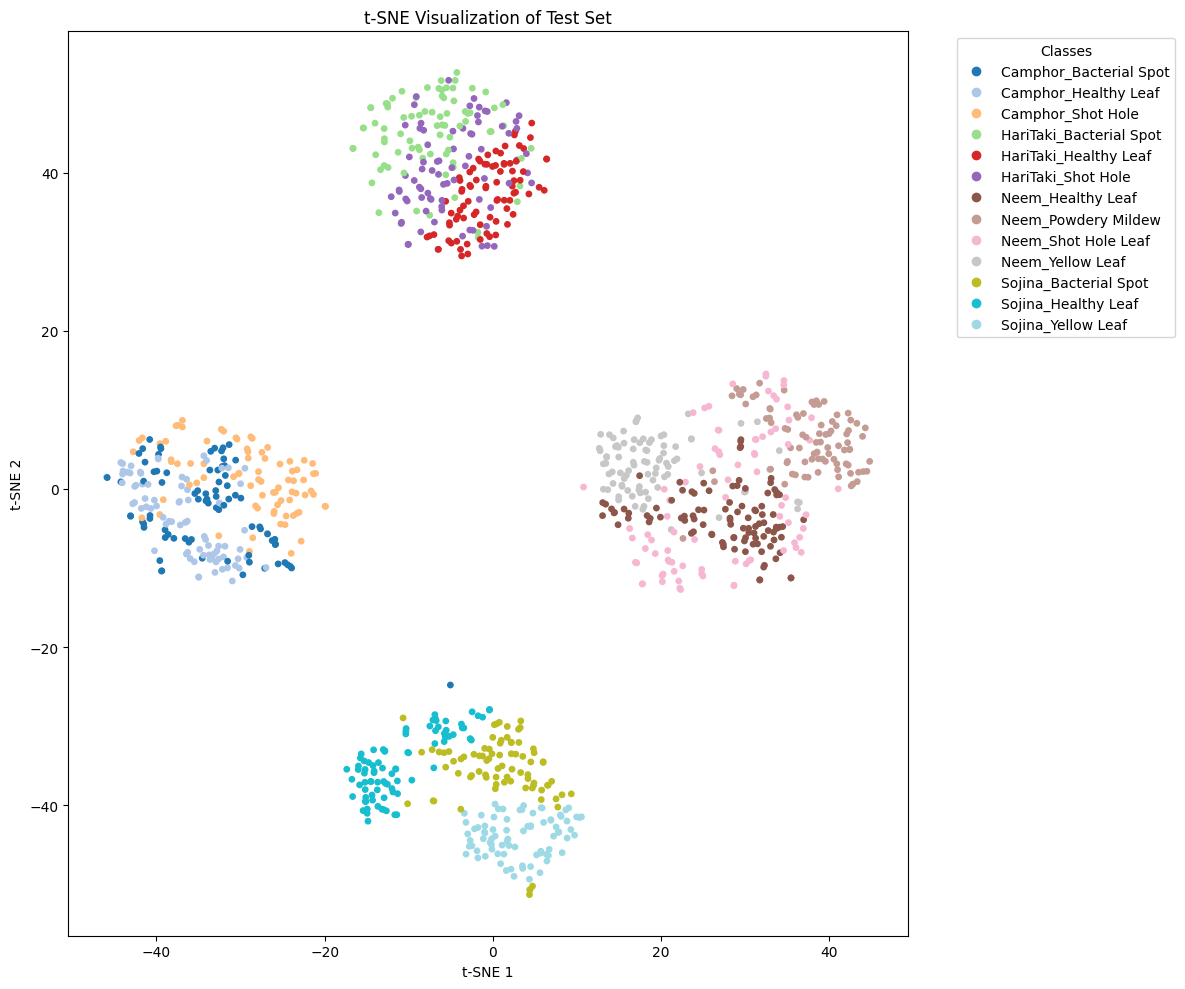

In [11]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# =========================================
# 1️⃣ Feature Extraction Function
# =========================================
def extract_features(model, loader, device='cuda'):
    model.eval()
    all_features = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            feats = model.get_features(images)  # Or model.forward_features(images)
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())
    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_features, all_labels

# =========================================
# 2️⃣ Extract Features from Test Loader
# =========================================
X_test, y_test = extract_features(model, test_loader, device='cuda')

# =========================================
# 3️⃣ t-SNE Dimensionality Reduction
# =========================================
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_test_tsne = tsne.fit_transform(X_test)

# =========================================
# 4️⃣ Map integer labels to class names
# =========================================
# Suppose you have class_to_idx mapping from training
idx_to_class = {v: k for k, v in class_to_idx.items()}  # invert dictionary
y_test_names = [idx_to_class[i] for i in y_test]

# =========================================
# 5️⃣ Plot t-SNE with class names
# =========================================
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=y_test, cmap='tab20', s=15)

# Create legend with actual class names
handles, _ = scatter.legend_elements()
unique_labels = np.unique(y_test)
plt.legend(handles, [idx_to_class[i] for i in unique_labels], title="Classes",
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("t-SNE Visualization of Test Set")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()


In [12]:
import numpy as np
import torch
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# ============================================================================
# 1. FEATURE EXTRACTION
# ============================================================================
def extract_features(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting features"):
            images = images.to(device)
            feats = model.get_features(images)
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    all_features = np.concatenate(all_features, axis=0)
    all_labels   = np.concatenate(all_labels, axis=0)
    return all_features, all_labels


# ============================================================================
# 2. EXTRACT TRAIN & TEST FEATURES
# ============================================================================
train_X, train_y = extract_features(model, train_loader, DEVICE)
test_X,  test_y  = extract_features(model, test_loader, DEVICE)


# ============================================================================
# 3. STANDARDIZE FEATURES
# ============================================================================
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
test_X  = scaler.transform(test_X)


# ============================================================================
# 4. PCA DIMENSIONALITY REDUCTION
# ============================================================================
pca = PCA(n_components=512, random_state=42)
train_X = pca.fit_transform(train_X)
test_X  = pca.transform(test_X)


# ============================================================================
# 5. DEFINE CLASSIFIERS
# ============================================================================
classifiers = {

    "SVM (RBF)": SVC(
        kernel="rbf",
        C=10.0,
        gamma="scale",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion="gini",
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,        # number of trees
        criterion="gini",        # or "entropy"
        max_depth=None,          # set e.g. 20 to reduce overfitting
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",     # common choice
        n_jobs=-1,               # use all CPU cores
        random_state=42
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(1024, 512, 256),
        activation='relu',
        solver='adam',
        learning_rate_init=0.00001,
        max_iter=1400,
        random_state=42,
        verbose=True
    )
}


# ============================================================================
# 6. TRAIN & EVALUATE ALL MODELS
# ============================================================================
results = {}

for name, clf in classifiers.items():
    print(f"\nTraining {name}...")
    clf.fit(train_X, train_y)

    preds = clf.predict(test_X)
    acc = accuracy_score(test_y, preds)

    results[name] = acc
    print(f"{name} Test Accuracy: {acc * 100:.2f}%")


# ============================================================================
# 7. FINAL SUMMARY
# ============================================================================
print("\n================ FINAL COMPARISON ================")
for name, acc in results.items():
    print(f"{name}: {acc * 100:.2f}%")

Extracting features: 100%|██████████| 34/34 [00:56<00:00,  1.68s/it]



Training SVM (RBF)...
SVM (RBF) Test Accuracy: 96.59%

Training Decision Tree...
Decision Tree Test Accuracy: 71.09%

Training Random Forest...
Random Forest Test Accuracy: 89.04%

Training MLP...
Iteration 1, loss = 2.46274855
Iteration 2, loss = 1.95996826
Iteration 3, loss = 1.56005281
Iteration 4, loss = 1.23477945
Iteration 5, loss = 0.98390119
Iteration 6, loss = 0.79913525
Iteration 7, loss = 0.66481239
Iteration 8, loss = 0.56587332
Iteration 9, loss = 0.49080499
Iteration 10, loss = 0.43244175
Iteration 11, loss = 0.38567766
Iteration 12, loss = 0.34745779
Iteration 13, loss = 0.31578225
Iteration 14, loss = 0.28898888
Iteration 15, loss = 0.26647424
Iteration 16, loss = 0.24648185
Iteration 17, loss = 0.22929155
Iteration 18, loss = 0.21401069
Iteration 19, loss = 0.20070238
Iteration 20, loss = 0.18866443
Iteration 21, loss = 0.17763783
Iteration 22, loss = 0.16802629
Iteration 23, loss = 0.15914522
Iteration 24, loss = 0.15078359
Iteration 25, loss = 0.14350841
Iteration 2

Plotting ROC for SVM (RBF)...
Plotting ROC for Decision Tree...


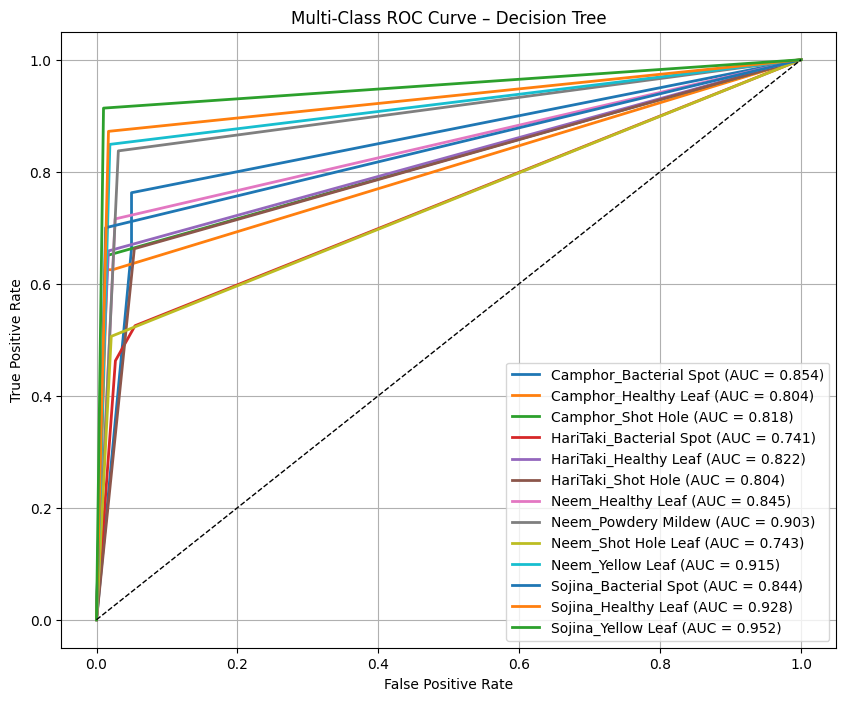

Plotting ROC for Random Forest...


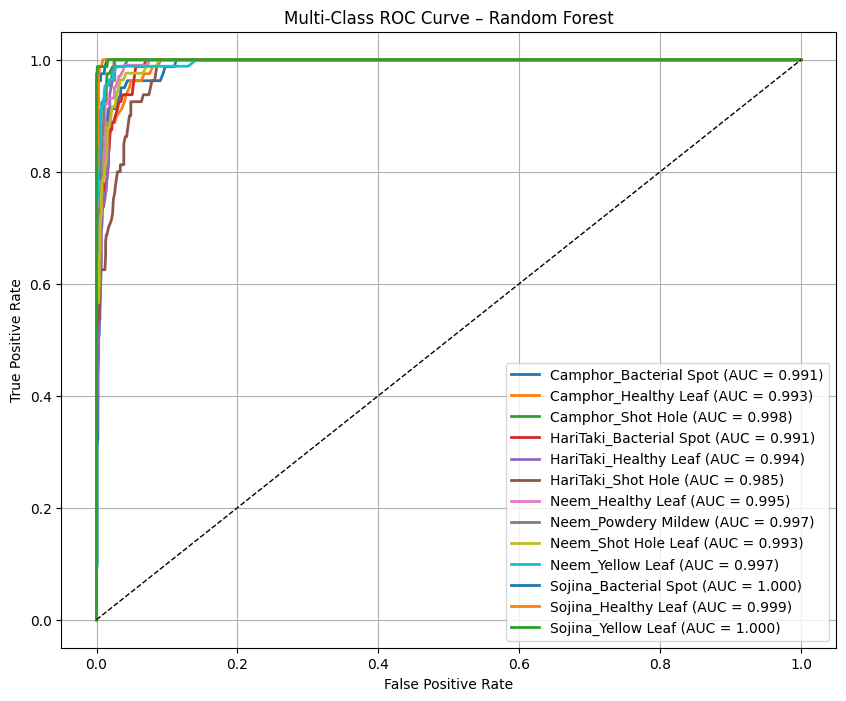

Plotting ROC for MLP...


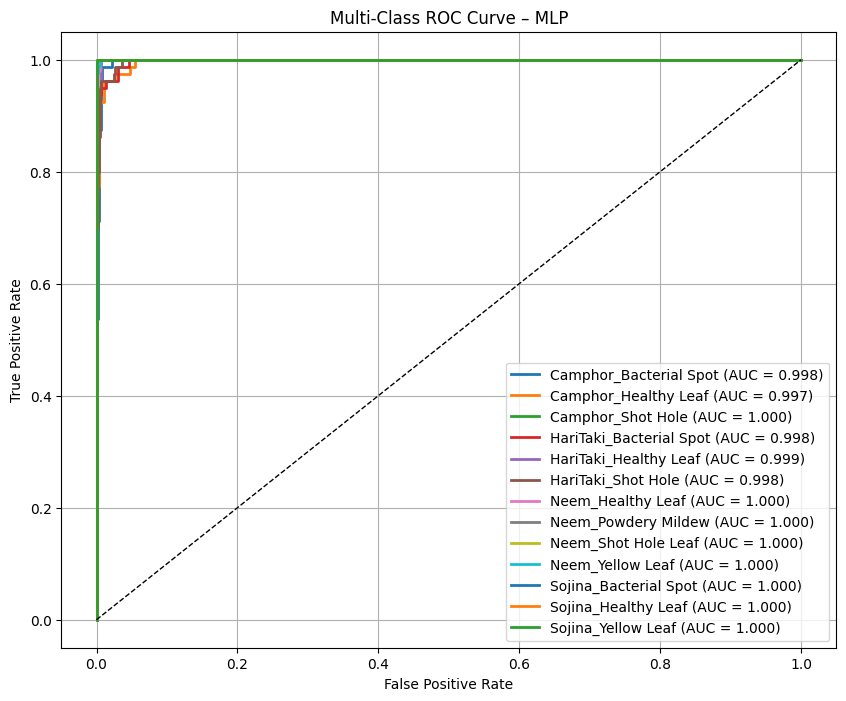

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# ============================================================================
# 7. MULTI-CLASS ROC PLOTTING FUNCTION
# ============================================================================
NUM_CLASSES = len(np.unique(test_y))
y_bin = label_binarize(test_y, classes=list(range(NUM_CLASSES)))

def plot_multiclass_roc(model, model_name, test_X, y_bin, class_names=None):
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(test_X)
    else:
        scores = model.decision_function(test_X)
        if scores.ndim == 1:
            scores = scores.reshape(-1,1)

    plt.figure(figsize=(10,8))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], scores[:, i])
        roc_auc = auc(fpr, tpr)
        label = f"{class_names[i]} (AUC = {roc_auc:.3f})" if class_names else f"Class {i} (AUC = {roc_auc:.3f})"
        plt.plot(fpr, tpr, lw=2, label=label)

    plt.plot([0,1],[0,1], "k--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Multi-Class ROC Curve – {model_name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# ============================================================================
# 8. PLOT ROC FOR ALL MODELS
# ============================================================================
# The 'classifiers' dictionary contains the trained models
for name, model in classifiers.items():
    print(f"Plotting ROC for {name}...")
    # Ensure SVM's predict_proba is callable or handle decision_function
    if name == "SVM (RBF)": # SVM needs probability=True during initialization
        if not hasattr(model, "predict_proba"):
            print(f"Warning: SVM model '{name}' does not have 'predict_proba'. Cannot plot ROC curve for this model.")
            continue
    plot_multiclass_roc(model, name, test_X, y_bin, class_names=list(idx_to_class.values()))


================ SVM (RBF) =================
✔️ Overall Test Accuracy: 96.59%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          97.50
Camphor_Healthy Leaf            82.50
Camphor_Shot Hole               98.75
HariTaki_Bacterial Spot         85.00
HariTaki_Healthy Leaf           98.78
HariTaki_Shot Hole              93.75
Neem_Healthy Leaf              100.00
Neem_Powdery Mildew             98.84
Neem_Shot Hole Leaf             98.80
Neem_Yellow Leaf               100.00
Sojina_Bacterial Spot          100.00
Sojina_Healthy Leaf            100.00
Sojina_Yellow Leaf             100.00

📄 Classification Report:
                         precision  recall  f1-score   support
Camphor_Bacterial Spot       0.848   0.975     0.907    80.000
Camphor_Healthy Leaf         0.957   0.825     0.886    80.000
Camphor_Shot Hole            1.000   0.988     0.994    80.000
HariTaki_Bacterial Spot      0.971   0.850     0.907    80.000
HariTaki_Healthy Leaf    

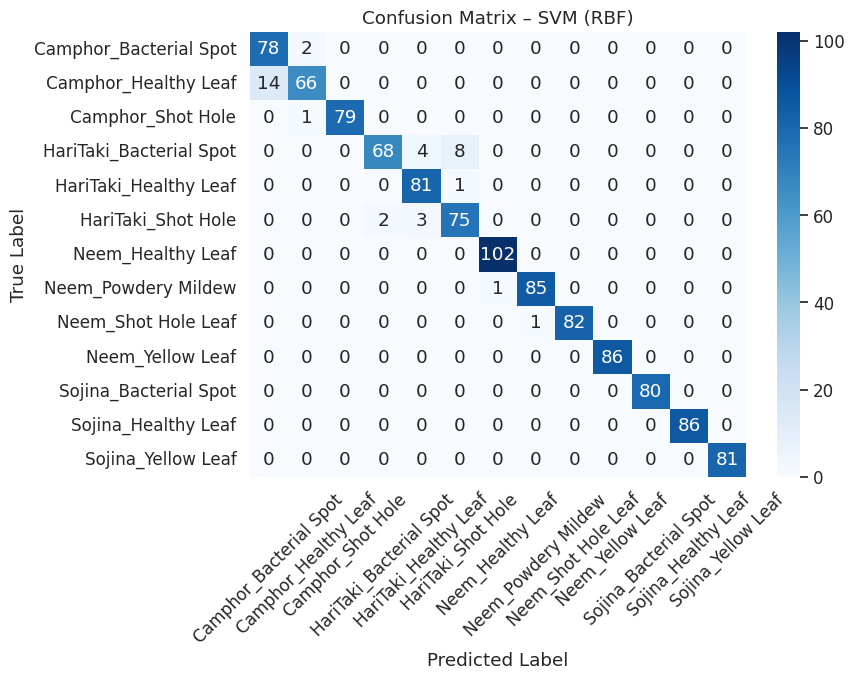


================ Decision Tree =================
✔️ Overall Test Accuracy: 71.09%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          76.25
Camphor_Healthy Leaf            62.50
Camphor_Shot Hole               65.00
HariTaki_Bacterial Spot         46.25
HariTaki_Healthy Leaf           65.85
HariTaki_Shot Hole              66.25
Neem_Healthy Leaf               71.57
Neem_Powdery Mildew             83.72
Neem_Shot Hole Leaf             50.60
Neem_Yellow Leaf                84.88
Sojina_Bacterial Spot           70.00
Sojina_Healthy Leaf             87.21
Sojina_Yellow Leaf              91.36

📄 Classification Report:
                         precision  recall  f1-score   support
Camphor_Bacterial Spot       0.550   0.762     0.639    80.000
Camphor_Healthy Leaf         0.769   0.625     0.690    80.000
Camphor_Shot Hole            0.788   0.650     0.712    80.000
HariTaki_Bacterial Spot      0.578   0.462     0.514    80.000
HariTaki_Healthy Leaf

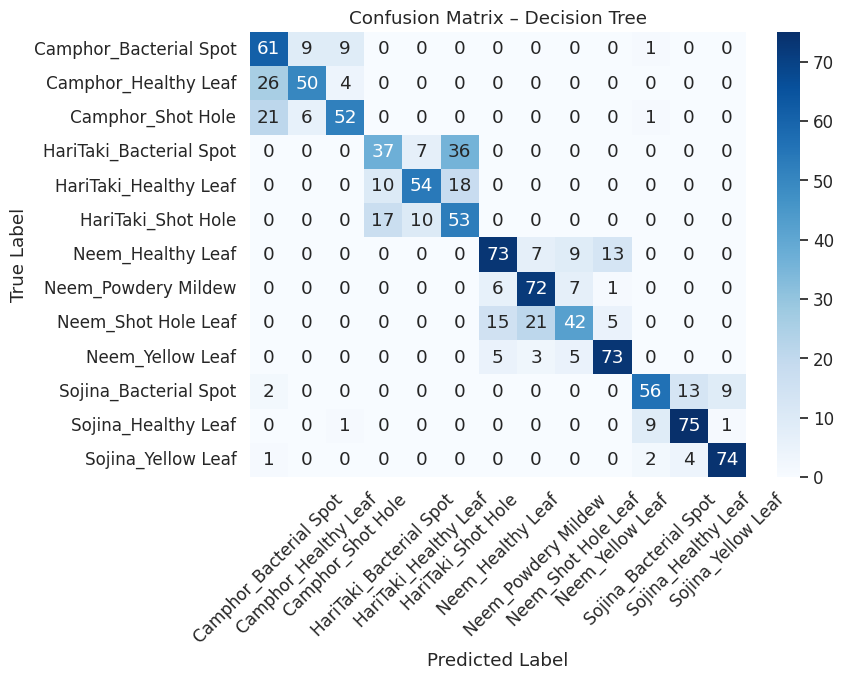


================ Random Forest =================
✔️ Overall Test Accuracy: 89.04%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          96.25
Camphor_Healthy Leaf            83.75
Camphor_Shot Hole               87.50
HariTaki_Bacterial Spot         70.00
HariTaki_Healthy Leaf           97.56
HariTaki_Shot Hole              76.25
Neem_Healthy Leaf               92.16
Neem_Powdery Mildew             93.02
Neem_Shot Hole Leaf             73.49
Neem_Yellow Leaf                93.02
Sojina_Bacterial Spot           92.50
Sojina_Healthy Leaf            100.00
Sojina_Yellow Leaf             100.00

📄 Classification Report:
                         precision  recall  f1-score  support
Camphor_Bacterial Spot       0.802   0.962     0.875    80.00
Camphor_Healthy Leaf         0.944   0.838     0.887    80.00
Camphor_Shot Hole            0.972   0.875     0.921    80.00
HariTaki_Bacterial Spot      0.918   0.700     0.794    80.00
HariTaki_Healthy Leaf     

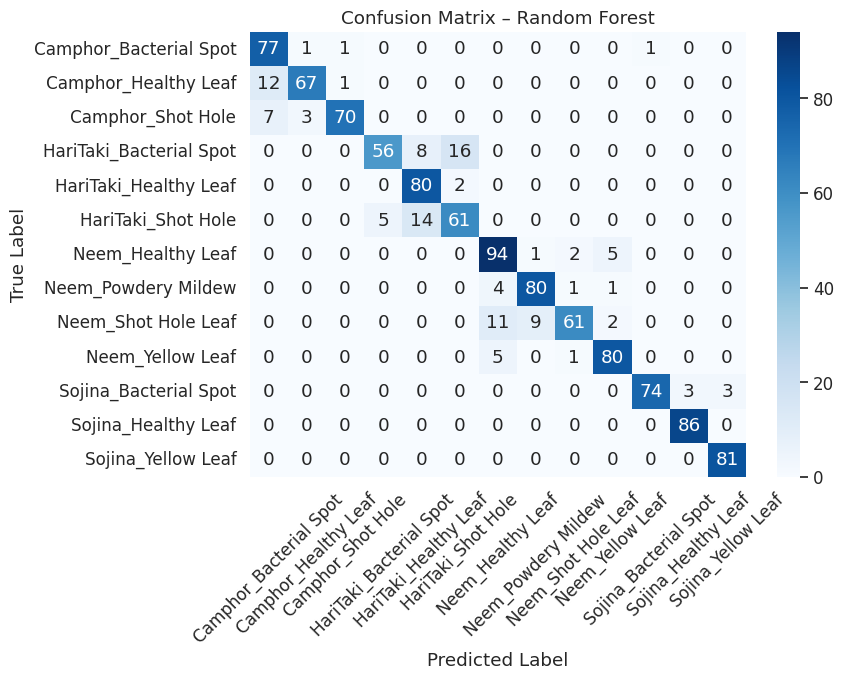


================ MLP =================
✔️ Overall Test Accuracy: 96.87%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          98.75
Camphor_Healthy Leaf            88.75
Camphor_Shot Hole               96.25
HariTaki_Bacterial Spot         83.75
HariTaki_Healthy Leaf          100.00
HariTaki_Shot Hole              96.25
Neem_Healthy Leaf               98.04
Neem_Powdery Mildew             98.84
Neem_Shot Hole Leaf             98.80
Neem_Yellow Leaf                98.84
Sojina_Bacterial Spot          100.00
Sojina_Healthy Leaf            100.00
Sojina_Yellow Leaf             100.00

📄 Classification Report:
                         precision  recall  f1-score   support
Camphor_Bacterial Spot       0.888   0.988     0.935    80.000
Camphor_Healthy Leaf         0.959   0.888     0.922    80.000
Camphor_Shot Hole            1.000   0.962     0.981    80.000
HariTaki_Bacterial Spot      0.985   0.838     0.905    80.000
HariTaki_Healthy Leaf        0.

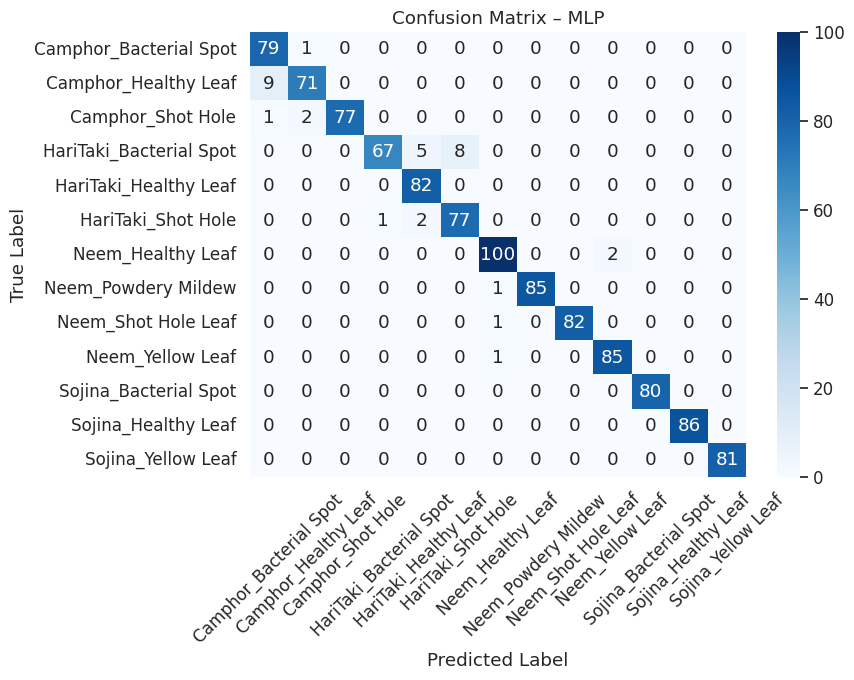


================ FINAL MODEL COMPARISON ================
               Accuracy  Macro Precision  Macro Recall  Macro F1  Accuracy (%)
SVM (RBF)        0.9659           0.9668        0.9645    0.9645       96.5930
Decision Tree    0.7109           0.7188        0.7088    0.7079       71.0866
Random Forest    0.8904           0.8977        0.8889    0.8890       89.0424
MLP              0.9687           0.9698        0.9679    0.9678       96.8692


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# EVALUATION FOR ALL MODELS
# ============================================================
all_results = {}

for model_name, model in classifiers.items():

    print(f"\n================ {model_name} =================")

    # ------------------------------
    # 1️⃣ Predictions
    # ------------------------------
    preds = model.predict(test_X)

    # ------------------------------
    # 2️⃣ Overall Accuracy
    # ------------------------------
    overall_acc = accuracy_score(test_y, preds)
    print(f"✔️ Overall Test Accuracy: {overall_acc * 100:.2f}%")

    # ------------------------------
    # 3️⃣ Per-Class Accuracy
    # ------------------------------
    per_class_acc = {}
    for c in range(NUM_CLASSES):
        idx = np.where(test_y == c)[0]
        class_acc = accuracy_score(test_y[idx], preds[idx])
        class_name = list(class_to_idx.keys())[c]
        per_class_acc[class_name] = class_acc * 100

    df_acc = pd.DataFrame.from_dict(
        per_class_acc, orient='index', columns=['Accuracy (%)']
    ).sort_index()

    print("\n📌 Per-Class Accuracy:")
    print(df_acc.to_string(float_format="%.2f"))

    # ------------------------------
    # 4️⃣ Classification Report
    # ------------------------------
    print("\n📄 Classification Report:")
    report = classification_report(
        test_y,
        preds,
        target_names=list(class_to_idx.keys()),
        digits=3,
        output_dict=True
    )
    df_report = pd.DataFrame(report).T
    print(df_report.round(3))

    # ------------------------------
    # 5️⃣ Macro Metrics
    # ------------------------------
    macro_precision = precision_score(test_y, preds, average="macro")
    macro_recall    = recall_score(test_y, preds, average="macro")
    macro_f1        = f1_score(test_y, preds, average="macro")

    print(f"\n🔹 Macro Precision: {macro_precision:.3f}")
    print(f"🔹 Macro Recall:    {macro_recall:.3f}")
    print(f"🔹 Macro F1-score:  {macro_f1:.3f}")

    # Save summary
    all_results[model_name] = {
        "Accuracy": overall_acc,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1
    }

    # ------------------------------
    # 6️⃣ Confusion Matrix
    # ------------------------------
    cm = confusion_matrix(test_y, preds)

    plt.figure(figsize=(9, 7))
    sns.set(font_scale=1.1)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=list(class_to_idx.keys()),
        yticklabels=list(class_to_idx.keys())
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


df_summary = pd.DataFrame(all_results).T
df_summary["Accuracy (%)"] = df_summary["Accuracy"] * 100

print("\n================ FINAL MODEL COMPARISON ================")
print(df_summary.round(4))



🔹 Training with 1% labeled data (87 samples)
SVM Accuracy: 65.47%
Decision Tree Accuracy: 39.04%
Random Forest Accuracy: 36.19%
MLP Accuracy: 65.65%

🔹 Training with 5% labeled data (439 samples)
SVM Accuracy: 84.07%
Decision Tree Accuracy: 51.57%
Random Forest Accuracy: 72.47%
MLP Accuracy: 84.90%

🔹 Training with 10% labeled data (879 samples)
SVM Accuracy: 89.59%
Decision Tree Accuracy: 59.12%
Random Forest Accuracy: 83.15%
MLP Accuracy: 90.61%

🔹 Training with 25% labeled data (2198 samples)
SVM Accuracy: 93.19%
Decision Tree Accuracy: 62.34%
Random Forest Accuracy: 86.37%
MLP Accuracy: 94.11%

🔹 Training with 50% labeled data (4397 samples)
SVM Accuracy: 94.57%
Decision Tree Accuracy: 63.54%
Random Forest Accuracy: 87.29%
MLP Accuracy: 95.76%


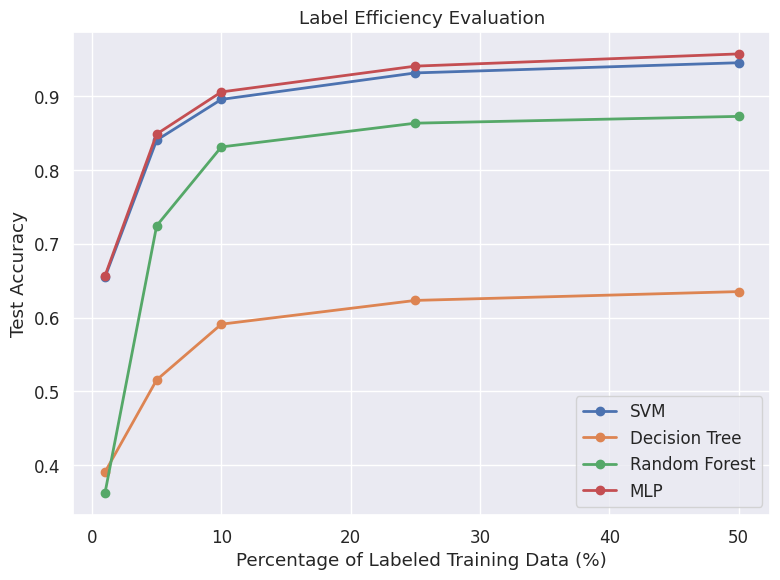

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# ------------------------------
# 1. Define labeled fractions
# ------------------------------
fractions = [0.01, 0.05, 0.10, 0.25, 0.50]
n_train = train_X.shape[0]

# Store results
results = {
    "SVM": [],
    "Decision Tree": [],
    "Random Forest": [],
    "MLP": []
}

# ------------------------------
# 2. Loop over fractions
# ------------------------------
for frac in fractions:
    n_samples = max(1, int(n_train * frac))
    np.random.seed(42)
    indices = np.random.choice(n_train, n_samples, replace=False)

    X_subset = train_X[indices]
    y_subset = train_y[indices]

    print(f"\n🔹 Training with {frac*100:.0f}% labeled data ({n_samples} samples)")

    # ---------- SVM ----------
    svm = SVC(kernel="rbf", C=10.0, gamma="scale")
    svm.fit(X_subset, y_subset)
    acc = accuracy_score(test_y, svm.predict(test_X))
    results["SVM"].append(acc)
    print(f"SVM Accuracy: {acc*100:.2f}%")

    # ---------- Decision Tree ----------
    dt = DecisionTreeClassifier(criterion="gini", max_depth=20, random_state=42)
    dt.fit(X_subset, y_subset)
    acc = accuracy_score(test_y, dt.predict(test_X))
    results["Decision Tree"].append(acc)
    print(f"Decision Tree Accuracy: {acc*100:.2f}%")

    # ---------- Random Forest ----------
    rf = RandomForestClassifier(n_estimators=300, max_features="sqrt", n_jobs=-1, random_state=42)
    rf.fit(X_subset, y_subset)
    acc = accuracy_score(test_y, rf.predict(test_X))
    results["Random Forest"].append(acc)
    print(f"Random Forest Accuracy: {acc*100:.2f}%")

    # ---------- MLP ----------
    mlp = MLPClassifier(
        hidden_layer_sizes=(1024, 512, 256),
        activation='relu',
        solver='adam',
        learning_rate_init=0.0001,
        max_iter=1000,
        random_state=42
    )
    mlp.fit(X_subset, y_subset)
    acc = accuracy_score(test_y, mlp.predict(test_X))
    results["MLP"].append(acc)
    print(f"MLP Accuracy: {acc*100:.2f}%")

# ------------------------------
# 3. Plot Accuracy vs Labeled Fraction
# ------------------------------
plt.figure(figsize=(8, 6))
for model_name, accs in results.items():
    plt.plot(
        [f * 100 for f in fractions],
        accs,
        marker='o',
        linewidth=2,
        label=model_name
    )

plt.xlabel("Percentage of Labeled Training Data (%)")
plt.ylabel("Test Accuracy")
plt.title("Label Efficiency Evaluation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
